# Homework 2A: Compare Browsing Sessions

Find browsing sessions similar to session **58**. Compare Euclidean distance, scaling, Manhattan distance, and cosine similarity, as in Lectures 03a and 03b. Then apply Jaccard similarity to a small purchase example.

Most code is supplied. Adapt the example calls and answer the questions below. You do not need your HW1B notebook.

## Data and setup

Each row describes one online shopping session using the recorded time spent on administrative, informational, and product-related pages. The data come from the [UCI Online Shoppers Purchasing Intention Dataset](https://doi.org/10.24432/C5F88Q) by Sakar and Kastro, licensed [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). This is the same source used in HW1B, with different columns selected.

The prepared file contains 11,610 sessions. We removed 720 rows with zero in all three duration columns so cosine is defined for every session. All comparisons use the same remaining rows. Values retain the source's duration units. `session_id` is a row label added by the course; it is not a feature. These records describe one site's sessions during one year, not all online shopping behavior.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from scipy.spatial.distance import cdist

sessions = pd.read_csv(
    "https://raw.githubusercontent.com/olearydj/INSY7130/"
    "main/homework/hw2a/data/browsing-session-durations.csv"
)
FEATURES = ["administrative", "informational", "product_related"]
ANCHOR = 58
K = 3
durations = sessions.set_index("session_id")[FEATURES]
feature_means = durations.mean()
feature_scales = durations.std(ddof=0)
standardized = (durations - feature_means) / feature_scales

display(durations.loc[[ANCHOR]])
display(pd.DataFrame({"minimum": durations.min(), "maximum": durations.max(),
                      "standard_deviation": feature_scales}).round(3))

,administrative,informational,product_related
session_id,,,
58,56.0,120.0,998.741667


,minimum,maximum,standard_deviation
administrative,0.0,3398.750,180.986
informational,0.0,2549.375,144.772
product_related,0.0,63973.522,1948.053


Rows in `durations` are sessions; columns are the three duration features. `durations.loc[[ANCHOR]]` selects session 58 as a one-row table. The supplied setup subtracts each column's mean and uses that column's standard deviation to create `standardized`.

The helpers below calculate and display the three nearest other sessions. `rank_neighbors` accepts a data matrix and a distance name, such as `"euclidean"` or `"cosine"`. `show_profiles` displays selected sessions and plots the percentage of each session's recorded time spent in each page category.

In [2]:
def rank_neighbors(matrix, metric):
    distances = cdist(matrix.loc[[ANCHOR]], matrix, metric=metric).ravel()
    ranking = pd.Series(distances, index=matrix.index, name="distance")
    ranking = ranking.drop(index=ANCHOR).sort_values(kind="stable").head(K)
    table = ranking.rename_axis("session_id").reset_index()
    table.index = pd.RangeIndex(1, len(table) + 1, name="rank")
    if metric == "cosine":
        table["similarity"] = 1 - table["distance"]
    return table


def show_ranking(table):
    with pd.option_context("display.float_format", "{:.8f}".format):
        display(table)


def show_profiles(candidate_ids):
    ids = list(dict.fromkeys([ANCHOR, *candidate_ids]))
    selected = durations.loc[ids]
    totals = selected.sum(axis=1)
    shares = selected.div(totals, axis=0)
    display(selected.assign(total_duration=totals).round(3))
    axis = shares.mul(100).plot.bar(
        figsize=(9, 4), color=["#0072B2", "#D55E00", "#009E73"], rot=0
    )
    axis.set_xlabel("Session ID")
    axis.set_ylabel("Share of recorded duration (%)")
    axis.set_ylim(0, 100)
    axis.set_title("Allocation across the three page categories")
    axis.legend(title="Page category", loc="upper left", bbox_to_anchor=(1.02, 1))
    axis.figure.tight_layout()
    plt.show()

## 1. Euclidean distance, scaling, and Manhattan distance

Run the raw Euclidean comparison below. Then adapt the call to find the nearest sessions using `standardized`. Save that result as `standardized_neighbors` and display it with `show_ranking`.

In [3]:
raw_neighbors = rank_neighbors(durations, "euclidean")
show_ranking(raw_neighbors)

,session_id,distance
rank,,
1,1918,30.18036785
2,7474,43.06394344
3,1811,44.96776700


In [5]:
# Obtain and display standardized_neighbors using the supplied example.
standardized_neighbors = rank_neighbors(standardized, "euclidean")
show_ranking(standardized_neighbors)

,session_id,distance
rank,,
1,1918,0.03669091
2,5160,0.16062695
3,604,0.16649912


**1a.** Does any session appear in both lists?

> Yes, 1918 is the closest match in both raw and standardized rankings because it appears in both rankings.

**1b.** Why can standardizing the features change the nearest sessions? Use the feature summary above to identify which duration has the largest variation. Does standardizing automatically make the comparison better? Explain briefly.

> Since the product_related feature has a higher standard deviation than the other features, unscaled Euclidean distance measures closeness only on that column. Standardizing doesn't automatically improve things; it simply trades that for equal weighting across features, which is a choice rather than a win-win.

Use `rank_neighbors` with `standardized` and `"cityblock"` (SciPy's name for Manhattan distance) to obtain `manhattan_neighbors`. Display the result with `show_ranking`.

In [6]:
# Obtain and display manhattan_neighbors using standardized durations.
manhattan_neighbors = rank_neighbors(standardized, "cityblock")
show_ranking(manhattan_neighbors)

,session_id,distance
rank,,
1,1918,0.06158992
2,5160,0.25710898
3,604,0.28138670


**1c.** Which neighbors appear in both the standardized Euclidean and Manhattan lists? Briefly explain how the two measures combine feature differences differently.

< All three sessions are included in both the standardized Euclidean and Manhattan lists; however, this is not always the case, and since Manhattan simply adds up absolute differences, several moderate deviations could outweigh a single significant difference.

**Code question 1.** In the line `standardized = (durations - feature_means) / feature_scales`, what happens to each column? Explain the subtraction and division in two or three sentences.

> Each column would be recentered to a mean of 0 by subtracting feature_means, and it would be rescaled to a value of 1, or "one standard deviation above the average," by dividing by feature_scales. This would put all three features on the same level and prevent any one feature from dominating a distance calculation simply because it is measured in larger numbers.

## 2. Cosine similarity

Use `rank_neighbors(durations, "cosine")` to obtain `cosine_neighbors`, then display it with `show_ranking`. Use the original durations for this comparison.

In [7]:
# Obtain and display cosine_neighbors using the supplied example.
cosine_neighbors = rank_neighbors(durations, "cosine")
show_ranking(cosine_neighbors)

,session_id,distance,similarity
rank,,,
1,1712,0.00000035,0.99999965
2,1918,0.00000620,0.99999380
3,2822,0.00002579,0.99997421


Use `show_profiles` to compare the first- and second-ranked sessions from your cosine results. The table shows durations and totals; the bars show percentages of each session's total. These percentages are not cosine scores.

,administrative,informational,product_related,total_duration
session_id,,,,
58,56.0,120.000,998.742,1174.742
1712,26.0,55.000,457.000,538.000
1918,51.0,117.286,969.102,1137.388


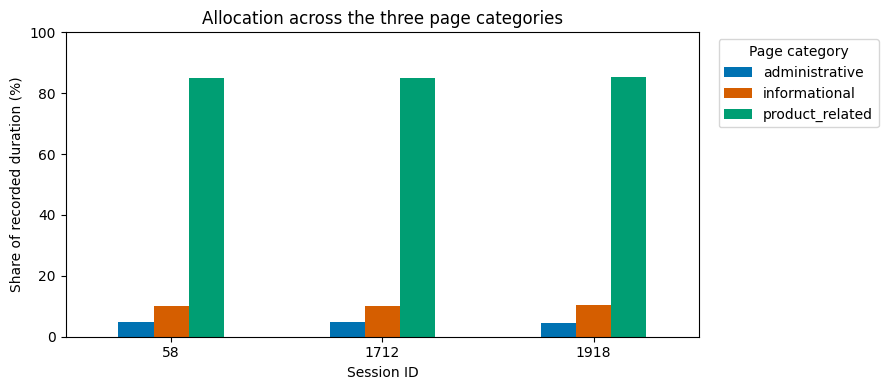

In [9]:
# Use show_profiles to compare the first- and second-ranked cosine sessions.
show_profiles ([1712, 1918])

**2a.** How does this list compare with the raw Euclidean distance result?

> Session 1918 is present in both lists, achieving first place in raw scores and second in cosine scores, although the remaining cosine top three sessions, 1712 and 2822, do not rank highly in the raw Euclidean list due to the differing nature of the metrics.

**2b.** Use the table and figure to explain how session 58 and the first-ranked cosine session can have high cosine similarity even though their total durations differ. Would Euclidean distance ignore this difference in total duration?

> The nearly identical page type percentage breakdowns of 4.8%, 10.2%, and 85% for sessions 58 and 1712, with total durations of 1174.7 and 538, respectively, explain why cosine similarity ranks them so closely even though Euclidean distance, which is sensitive to raw magnitude, treats them as far apart.

**2c.** Does appearing in the top three guarantee that a session is useful for a particular business question? Explain briefly.

> Replace this text with your answer to 2c.

**Code question 2.** In `rank_neighbors`, why do we use `drop(index=ANCHOR)`? Why is sorting distance from smallest to largest appropriate, even though larger cosine similarities indicate a closer match? Use the `1 - distance` calculation in your explanation. Two or three sentences are sufficient.

> Replace this text with your answer to Code question 2.

## 3. Jaccard similarity

In this small made-up purchase example, 1 means a customer bought a product and 0 means they did not. Run the supplied code to compare customers A–D with Target using Jaccard similarity.

In [10]:
purchases = pd.DataFrame(
    [[1, 1, 1, 0, 0, 0, 0, 0],
     [1, 1, 1, 1, 1, 1, 1, 0],
     [1, 1, 0, 0, 0, 0, 0, 0],
     [1, 0, 0, 1, 0, 0, 0, 0],
     [0, 0, 0, 0, 1, 0, 0, 0]],
    index=["Target", "A", "B", "C", "D"],
    columns=[f"P{i}" for i in range(1, 9)],
)
others = purchases.drop(index="Target")
jaccard_scores = pd.Series(
    1 - cdist(purchases.loc[["Target"]].to_numpy(dtype=bool),
              others.to_numpy(dtype=bool), metric="jaccard").ravel(),
    index=others.index, name="Jaccard similarity",
).sort_values(ascending=False)
display(purchases)
display(jaccard_scores.round(4).to_frame())

,P1,P2,P3,P4,P5,P6,P7,P8
Target,1,1,1,0,0,0,0,0
A,1,1,1,1,1,1,1,0
B,1,1,0,0,0,0,0,0
C,1,0,0,1,0,0,0,0
D,0,0,0,0,1,0,0,0


,Jaccard similarity
B,0.6667
A,0.4286
C,0.2500
D,0.0000


**3a.** Which customer is most similar to Target?

> Replace this text with your answer to 3a.

**3b.** Check customer A's score by identifying the intersection and union of its product set with Target's. Why doesn't the largest number of shared products necessarily give the highest Jaccard similarity?

> Replace this text with your answer to 3b.

**3c.** No customer bought P8. Why doesn't that shared absence contribute to Jaccard similarity?

> Replace this text with your answer to 3c.

## Check and submit

Answer each question briefly; a few sentences are enough for each explanation. Before submitting, restart the runtime and run all cells in order. Check that your answers agree with the session rankings, purchase comparison, and figure, and keep the outputs in your downloaded `.ipynb` file.

You may use course materials, documentation, and LLM assistance for explanation and debugging. Your submitted answers must be your own, and you must be able to explain the work.

**Assistance disclosure:** Identify material assistance and how you checked it. Write `None` if you received no material assistance.

> Replace this text with your disclosure.

**Optional, ungraded feedback:** Approximately how much active time did you spend, excluding breaks? Which part required the most effort, and was anything unclear?

> Optional feedback.